# MLOps Lab 4: Model Training, Evaluation & Serialization

## Aim
To train multiple machine learning classification models using the Kidney Disease dataset, evaluate their performance, compare the models, select the best model, and save it for later use.

**This notebook is self-contained.** It starts from `kidney_disease.csv`, so it does not require `X_train_processed.csv`, `X_test_processed.csv`, or `preprocessing_pipeline.pkl`.

## Learning Outcomes

Students will be able to:
1. Load a dataset and understand its structure.
2. Separate features and target.
3. Split data into training and testing sets.
4. Build automated preprocessing pipelines.
5. Train multiple classification models.
6. Evaluate models using accuracy, precision, recall and F1-score.
7. Compare models and select the best model.
8. Save and load the complete preprocessing + model pipeline.

## Problem Statement

Build a machine learning system to classify kidney disease records using the available patient features.

**Dataset:** `kidney_disease.csv`

**Target:** `classification`

The `id` column is treated as an identifier and is not used as a machine-learning feature.

## MLOps Workflow

```text
Raw Dataset
     |
     v
Preprocessing
     |
     v
Train-Test Split
     |
     v
Model Training
     |
     +--> Logistic Regression
     +--> Decision Tree
     +--> Random Forest
     +--> KNN
     +--> SVM
     +--> Naive Bayes
     |
     v
Model Evaluation
     |
     v
Model Comparison
     |
     v
Best Model
     |
     v
Save Complete Pipeline
     |
     v
Future Prediction / Deployment
```

## Step 1: Import Required Libraries

In [1]:
# Import pandas for loading and manipulating data
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import train_test_split for creating training and testing sets
from sklearn.model_selection import train_test_split

# Import Pipeline to combine preprocessing and a model
from sklearn.pipeline import Pipeline

# Import ColumnTransformer to apply different preprocessing to different columns
from sklearn.compose import ColumnTransformer

# Import SimpleImputer to handle missing values
from sklearn.impute import SimpleImputer

# Import preprocessing techniques
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Import joblib to save and load the trained pipeline
import joblib

# Import os to check saved files
import os

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Kidney Disease Dataset

In [2]:
# Read the original Kidney Disease CSV file
df = pd.read_csv("kidney_disease_cleaned.csv")

# Display the first five records
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## Step 3: Understand the Dataset

In [3]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display the data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (400, 26)

Column Names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Data Types:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object


## Step 4: Check the Target Distribution

In [4]:
# Count records in each target class
print(df["classification"].value_counts())

# Display class percentages
print("\nClass Percentage:")
print(df["classification"].value_counts(normalize=True) * 100)

classification
ckd       250
notckd    150
Name: count, dtype: int64

Class Percentage:
classification
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64


## Step 5: Separate Features and Target

The `classification` column is the target.

The `id` column is removed because it is an identifier and should not be used as a predictive feature.

In [5]:
# Remove id and classification from the input features
X = df.drop(["id", "classification"], axis=1)

# Store the target column
y = df["classification"]

# Display the feature names
print("Number of Features:", X.shape[1])
print("Features:")
print(X.columns.tolist())

# Display target classes
print("\nTarget Classes:")
print(y.unique())

Number of Features: 24
Features:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Target Classes:
['ckd' 'notckd']


## Step 6: Identify Numerical and Categorical Columns

In [6]:
# Identify numerical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Identify categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(num_cols.tolist())

print("\nCategorical Columns:")
print(cat_cols.tolist())

Numerical Columns:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

Categorical Columns:
['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


## Step 7: Split the Dataset

The dataset is divided into:
- 80% training data
- 20% testing data

The preprocessing steps will learn their values only from the training data.

In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset sizes
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (320, 24)
Testing Features : (80, 24)
Training Target  : (320,)
Testing Target   : (80,)


## Step 8: Create Numerical Preprocessing Pipeline

For numerical columns:
1. Missing values are replaced by the mean.
2. Values are standardized using `StandardScaler`.

In [8]:
# Create the numerical preprocessing pipeline
numeric_pipeline = Pipeline([
    # Replace missing numerical values with the mean
    ("imputer", SimpleImputer(strategy="mean")),

    # Standardize numerical features
    ("scaler", StandardScaler())
])

print("Numerical pipeline created.")

Numerical pipeline created.


## Step 9: Create Categorical Preprocessing Pipeline

For categorical columns:
1. Missing values are replaced by the most frequent value.
2. Categories are converted to numerical form using One-Hot Encoding.
3. Unknown categories are ignored during prediction.

In [9]:
# Create the categorical preprocessing pipeline
categorical_pipeline = Pipeline([
    # Replace missing categorical values with the most frequent value
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Convert categorical values into numerical columns
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

print("Categorical pipeline created.")

Categorical pipeline created.


## Step 10: Combine the Preprocessing Pipelines

In [10]:
# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    # Apply numerical pipeline to numerical columns
    ("num", numeric_pipeline, num_cols),

    # Apply categorical pipeline to categorical columns
    ("cat", categorical_pipeline, cat_cols)
])

print("Complete preprocessing component created.")

Complete preprocessing component created.


## Step 11: Define Machine Learning Models

We will compare six classification algorithms:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine
- Naive Bayes

In [11]:
# Create the machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

# Display model names
for name in models:
    print(name)

Logistic Regression
Decision Tree
Random Forest
KNN
SVM
Naive Bayes


## Step 12: Create a Complete Pipeline for Every Model

Each model uses the same preprocessing steps.

```text
Raw Data
   |
   v
Preprocessing
   |
   +-- Missing Value Imputation
   +-- Encoding
   +-- Scaling
   |
   v
Machine Learning Model
```

In [12]:
# Create an empty dictionary for the complete pipelines
pipelines = {}

# Build one preprocessing + model pipeline for each algorithm
for name, model in models.items():

    # Combine preprocessing and model
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

print("Complete pipelines created.")

Complete pipelines created.


## Step 13: Train All Models

In [13]:
# Create a dictionary to store trained pipelines
trained_models = {}

# Train every pipeline
for name, pipeline in pipelines.items():

    # Fit preprocessing and model using training data
    pipeline.fit(X_train, y_train)

    # Store the trained pipeline
    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
KNN trained successfully.
SVM trained successfully.
Naive Bayes trained successfully.


## Step 14: Evaluate All Models

We calculate:
- Accuracy
- Precision
- Recall
- F1-score

F1-score is useful because it combines precision and recall into one measure.

In [14]:
# Create an empty list for evaluation results
results = []

# Evaluate each trained pipeline
for name, pipeline in trained_models.items():

    # Predict the unseen test data
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Calculate weighted precision
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Calculate weighted recall
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Calculate weighted F1-score
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store the results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Sort models by F1-score
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

# Display comparison table
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000,1.000000,1.000,1.000000
1,Random Forest,1.000,1.000000,1.000,1.000000
2,SVM,1.000,1.000000,1.000,1.000000
3,KNN,0.975,0.975000,0.975,0.975000
4,Decision Tree,0.950,0.950549,0.950,0.949628
5,Naive Bayes,0.950,0.950549,0.950,0.949628


## Step 15: Visualize Model Comparison

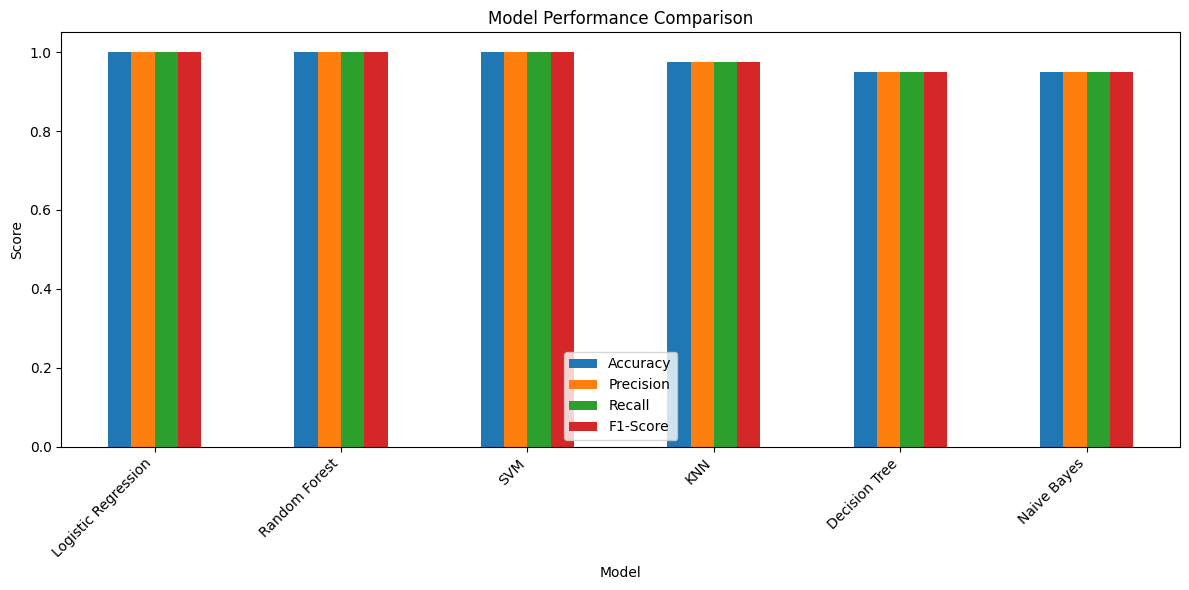

In [15]:
# Use model names as the chart index
plot_df = results_df.set_index("Model")

# Plot the evaluation metrics
plot_df[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

# Add title
plt.title("Model Performance Comparison")

# Add y-axis label
plt.ylabel("Score")

# Keep scores between 0 and 1
plt.ylim(0, 1.05)

# Rotate model names for readability
plt.xticks(rotation=45, ha="right")

# Adjust spacing
plt.tight_layout()

# Display chart
plt.show()

## Step 16: Select the Best Model

In [16]:
# Select the first row because the results are sorted by F1-score
best_model_name = results_df.iloc[0]["Model"]

# Retrieve the trained pipeline for the best model
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("Best F1-Score:", results_df.iloc[0]["F1-Score"])

Best Model: Logistic Regression
Best F1-Score: 1.0


## Step 17: Detailed Evaluation of the Best Model

In [17]:
# Generate predictions using the best pipeline
best_predictions = best_model.predict(X_test)

# Display a detailed classification report
print(classification_report(
    y_test,
    best_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

         ckd       1.00      1.00      1.00        50
      notckd       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## Step 18: Confusion Matrix

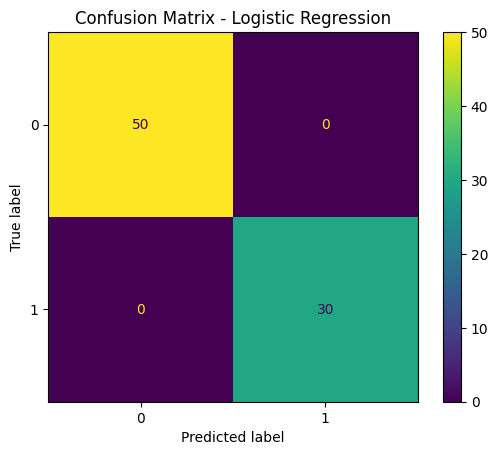

In [18]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, best_predictions)

# Create a confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

# Display the confusion matrix
disp.plot()

# Add a title
plt.title(f"Confusion Matrix - {best_model_name}")

# Display the figure
plt.show()

## Step 19: Save the Best Complete Pipeline

We save **preprocessing + model together**.

This is important in MLOps because the same preprocessing must be used when the model is deployed.

In [19]:
# Define the output file name
model_filename = "best_kidney_disease_pipeline.pkl"

# Save the complete trained pipeline
joblib.dump(
    best_model,
    model_filename
)

print("Best pipeline saved successfully.")
print("Saved file:", model_filename)

Best pipeline saved successfully.
Saved file: best_kidney_disease_pipeline.pkl


## Step 20: Verify the Saved Model

In [20]:
# Check whether the saved model file exists
if os.path.exists(model_filename):
    print("Saved model found:", model_filename)
else:
    print("Model file was not found.")

Saved model found: best_kidney_disease_pipeline.pkl


## Step 21: Load the Saved Pipeline

In [21]:
# Load the saved complete pipeline
loaded_model = joblib.load(model_filename)

print("Saved pipeline loaded successfully.")

Saved pipeline loaded successfully.


## Step 22: Test the Loaded Pipeline

In [22]:
# Use the loaded pipeline to make predictions
loaded_predictions = loaded_model.predict(X_test)

# Calculate accuracy after loading
loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print("Accuracy of Loaded Pipeline:", loaded_accuracy)

Accuracy of Loaded Pipeline: 1.0


## Step 23: Save Model Comparison Results

In [23]:
# Save the model comparison table
results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


## MLOps Perspective

This lab covers:

```text
Data
  |
  v
Preprocessing
  |
  v
Training
  |
  v
Evaluation
  |
  v
Model Selection
  |
  v
Model Serialization
  |
  v
Deployment
```

The saved `best_kidney_disease_pipeline.pkl` contains both preprocessing and the selected model.

### Next Lab
The next step is **MLflow Experiment Tracking**, where we can record model parameters, metrics and artifacts for every experiment.

## Output Files

After running the notebook, you should have:

```text
kidney_disease.csv
best_kidney_disease_pipeline.pkl
model_comparison_results.csv
```

The most important file is:

`best_kidney_disease_pipeline.pkl`

## Viva Questions

1. Why is the `id` column removed?
2. Why do we split data into training and testing sets?
3. Why should preprocessing be learned from training data?
4. What is a Pipeline?
5. What is the purpose of ColumnTransformer?
6. What is the difference between accuracy, precision, recall and F1-score?
7. What is a confusion matrix?
8. Why save preprocessing and model together?
9. What is Joblib used for?
10. How can the saved pipeline be used during deployment?

## Student Assignment

1. Run all six models.
2. Record accuracy, precision, recall and F1-score.
3. Identify the best model.
4. Explain why it was selected.
5. Save the best complete pipeline.
6. Load the saved pipeline and verify its predictions.
7. Write a short conclusion explaining why combining preprocessing and the model into one pipeline is useful in MLOps.